# Lista 7

## Zadanie 1 - Implementacja klasy Graph

In [2]:
from typing import Any, Optional
import matplotlib.pyplot as plt
import math


class Graph:
    DEFAULT_WEIGHT = 1
    
    def __init__(self, directed: bool = False):
        """
        Tworzy nowy, pusty graf.
        """
        self._adjacency_list: dict[Any, dict[Any, float]] = {}
        self._directed = directed
    
    @property
    def directed(self) -> bool:
        """Zwraca True jeśli graf jest skierowany."""
        return self._directed
    
    def add_vertex(self, vert: Any) -> None:
        """Dodaje wierzchołek do grafu."""
        if vert not in self._adjacency_list:
            self._adjacency_list[vert] = {}
    
    def add_vertices_from_list(self, vert_list: list) -> None:
        """Dodaje listę wierzchołków do grafu."""
        for vert in vert_list:
            self.add_vertex(vert)
    
    def add_edge(self, from_vert: Any, to_vert: Any, weight: float = None) -> None:
        """
        Dodaje krawędź między wierzchołkami.
        
        Jeśli wierzchołki nie istnieją, zostaną automatycznie dodane.
        """
        if weight is None:
            weight = self.DEFAULT_WEIGHT
            
        self.add_vertex(from_vert)
        self.add_vertex(to_vert)
        
        self._adjacency_list[from_vert][to_vert] = weight
        
        if not self._directed:
            self._adjacency_list[to_vert][from_vert] = weight
    
    def add_edges_from_list(self, edge_list: list) -> None:
        """
        Dodaje listę krawędzi do grafu.
        """
        for edge in edge_list:
            if len(edge) == 2:
                self.add_edge(edge[0], edge[1])
            elif len(edge) == 3:
                self.add_edge(edge[0], edge[1], edge[2])
    
    def get_vertices(self) -> list:
        """Zwraca listę wszystkich wierzchołków w grafie."""
        return list(self._adjacency_list.keys())
    
    def get_edges(self) -> list[tuple]:
        """
        Zwraca listę wszystkich krawędzi w grafie.
        """
        edges = []
        seen = set()
        
        for v1 in self._adjacency_list:
            for v2, weight in self._adjacency_list[v1].items():
                if self._directed:
                    edges.append((v1, v2, weight))
                else:
                    edge_key = tuple(sorted([str(v1), str(v2)]))
                    if edge_key not in seen:
                        edges.append((v1, v2, weight))
                        seen.add(edge_key)
        return edges
    
    def get_neighbors(self, vert_key: Any) -> list:
        """
        Zwraca listę wszystkich sąsiadów wierzchołka.
        """
        if vert_key not in self._adjacency_list:
            return []
        return list(self._adjacency_list[vert_key].keys())
    
    def get_weight(self, from_vert: Any, to_vert: Any) -> Optional[float]:
        """Zwraca wagę krawędzi lub None jeśli krawędź nie istnieje."""
        if from_vert in self._adjacency_list:
            return self._adjacency_list[from_vert].get(to_vert)
        return None
    
    def __contains__(self, vertex: Any) -> bool:
        """Sprawdza czy wierzchołek jest w grafie (vertex in graph)."""
        return vertex in self._adjacency_list
    
    def __len__(self) -> int:
        """Zwraca liczbę wierzchołków."""
        return len(self._adjacency_list)
    
    def __repr__(self) -> str:
        graph_type = "skierowany" if self._directed else "nieskierowany"
        return f"Graph({graph_type}, wierzchołki={len(self)}, krawędzie={len(self.get_edges())})"

In [3]:
g = Graph(directed=True)

g.add_vertex('A')
g.add_vertices_from_list(['B', 'C', 'D', 'E'])

g.add_edge('A', 'B')
g.add_edge('A', 'C', 2.5)
g.add_edge('B', 'D', 3)
g.add_edge('C', 'D')
g.add_edge('D', 'E', 1.5)

g.add_edges_from_list([('E', 'A'), ('B', 'C', 0.5)])

print(f"Graf: {g}")
print(f"Wierzchołki: {g.get_vertices()}")
print(f"Krawędzie: {g.get_edges()}")
print(f"Sąsiedzi A: {g.get_neighbors('A')}")
print(f"Waga A->C: {g.get_weight('A', 'C')}")

print(f"'A' in g: {'A' in g}")
print(f"'Z' in g: {'Z' in g}")

assert 'A' in g
assert 'Z' not in g
assert g.get_weight('A', 'C') == 2.5
assert g.get_weight('A', 'B') == 1
assert set(g.get_neighbors('A')) == {'B', 'C'}

Graf: Graph(skierowany, wierzchołki=5, krawędzie=7)
Wierzchołki: ['A', 'B', 'C', 'D', 'E']
Krawędzie: [('A', 'B', 1), ('A', 'C', 2.5), ('B', 'D', 3), ('B', 'C', 0.5), ('C', 'D', 1), ('D', 'E', 1.5), ('E', 'A', 1)]
Sąsiedzi A: ['B', 'C']
Waga A->C: 2.5
'A' in g: True
'Z' in g: False


## Zadanie 2 - Zapis do DOT i rysowanie grafu

Dodajemy metody:
- `save_graph(filename)` - zapisuje reprezentację grafu w formacie DOT do pliku
- `draw()` - rysuje graf przy użyciu matplotlib

In [4]:
def to_dot(self) -> str:
    """
    Generuje reprezentację grafu w języku DOT.
    """
    if self._directed:
        lines = ["digraph G {"]
        edge_symbol = "->"
    else:
        lines = ["graph G {"]
        edge_symbol = "--"
    
    lines.append("    rankdir=LR;")
    lines.append("    node [shape=circle];")
    
    # Dodaj wierzchołki
    for vertex in self._adjacency_list:
        lines.append(f'    "{vertex}";')
    
    # Dodaj krawędzie z wagami
    for v1, v2, weight in self.get_edges():
        if weight != 1:
            lines.append(f'    "{v1}" {edge_symbol} "{v2}" [label="{weight}"];')
        else:
            lines.append(f'    "{v1}" {edge_symbol} "{v2}";')
    
    lines.append("}")
    return "\n".join(lines)


def save_graph(self, filename: str) -> None:
    """
    Zapisuje reprezentację grafu w formacie DOT do pliku.
    """
    if not filename.endswith('.dot'):
        filename += '.dot'
    
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(self.to_dot())
    
    print(f"Graf zapisano do pliku: {filename}")


def draw(self, figsize: tuple = (10, 8), node_size: int = 700) -> None:
    """
    Rysuje graf.
    """
    vertices = self.get_vertices()
    n = len(vertices)
    
    if n == 0:
        print("Graf jest pusty.")
        return
    
    # Rozmieszczenie wierzchołków na okręgu
    pos = {}
    for i, v in enumerate(vertices):
        angle = 2 * math.pi * i / n
        pos[v] = (math.cos(angle), math.sin(angle))
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Rysowanie krawędzi
    for v1, v2, weight in self.get_edges():
        x1, y1 = pos[v1]
        x2, y2 = pos[v2]
        
        if self._directed:
            # Strzałka dla grafu skierowanego
            dx, dy = x2 - x1, y2 - y1
            length = math.sqrt(dx**2 + dy**2)
            if length > 0:
                shrink = 0.15
                x2_adj = x2 - shrink * dx / length
                y2_adj = y2 - shrink * dy / length
                ax.annotate('', xy=(x2_adj, y2_adj), xytext=(x1, y1),
                           arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
        else:
            ax.plot([x1, x2], [y1, y2], 'gray', linewidth=1.5, zorder=1)
        
        # Etykieta wagi (jeśli != 1)
        if weight != 1:
            mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
            ax.text(mid_x, mid_y, f'{weight}', fontsize=9, ha='center', va='center',
                   bbox=dict(boxstyle='round', facecolor='white', edgecolor='none', alpha=0.7))
    
    # Rysowanie wierzchołków
    for v in vertices:
        x, y = pos[v]
        circle = plt.Circle((x, y), 0.1, color='lightblue', ec='darkblue', linewidth=2, zorder=2)
        ax.add_patch(circle)
        ax.text(x, y, str(v), fontsize=10, ha='center', va='center', fontweight='bold', zorder=3)
    
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    graph_type = "Graf skierowany" if self._directed else "Graf nieskierowany"
    ax.set_title(f"{graph_type} ({len(vertices)} wierzchołków, {len(self.get_edges())} krawędzi)")
    
    plt.tight_layout()
    plt.show()


Graph.to_dot = to_dot
Graph.save_graph = save_graph
Graph.draw = draw

Reprezentacja DOT:
digraph G {
    rankdir=LR;
    node [shape=circle];
    "A";
    "B";
    "C";
    "D";
    "E";
    "A" -> "B";
    "A" -> "C" [label="2.5"];
    "B" -> "D" [label="3"];
    "C" -> "D";
    "D" -> "E" [label="1.5"];
    "E" -> "A" [label="2"];
}

Graf zapisano do pliku: graf_przykladowy.dot


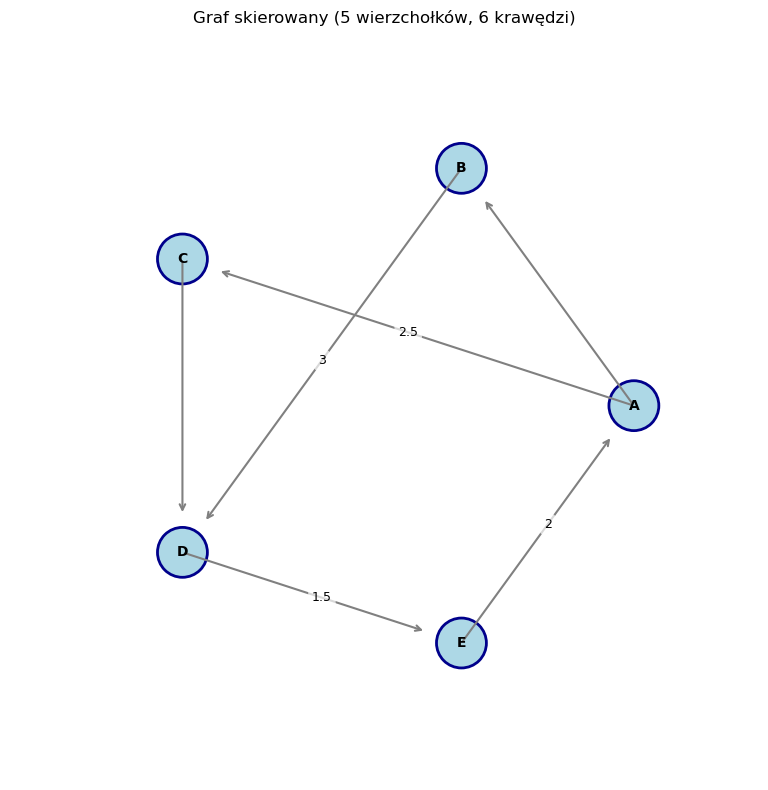

In [5]:
g = Graph(directed=True)
g.add_edges_from_list([
    ('A', 'B', 1),
    ('A', 'C', 2.5),
    ('B', 'D', 3),
    ('C', 'D', 1),
    ('D', 'E', 1.5),
    ('E', 'A', 2)
])

print("Reprezentacja DOT:")
print(g.to_dot())
print()

g.save_graph('graf_przykladowy')

g.draw()

Graf nieskierowany - DOT:
graph G {
    rankdir=LR;
    node [shape=circle];
    "A";
    "B";
    "C";
    "D";
    "A" -- "B";
    "A" -- "D";
    "A" -- "C";
    "B" -- "C";
    "C" -- "D";
}


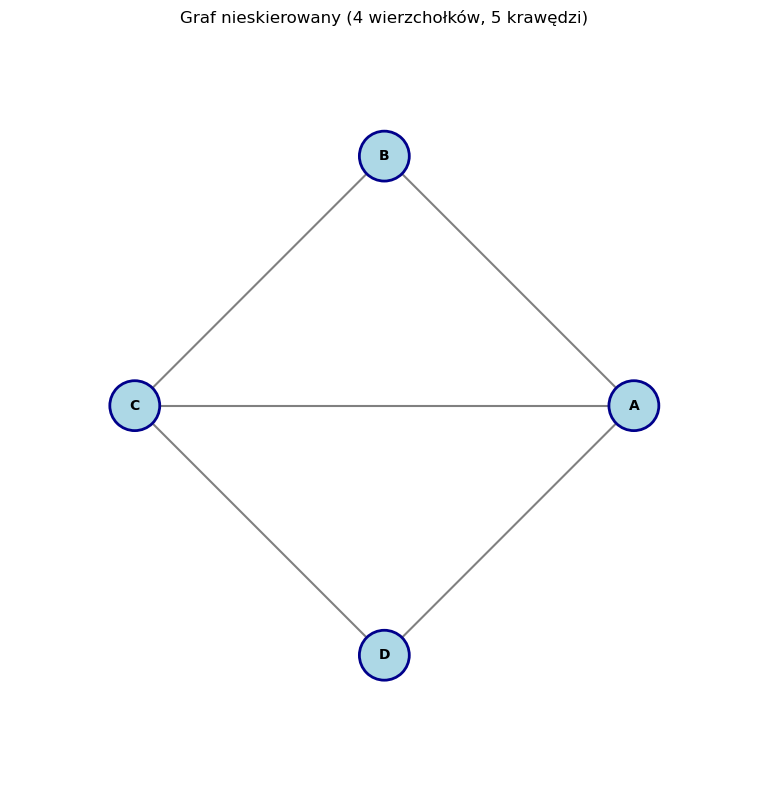

In [6]:
# Graf nieskierowany
g2 = Graph(directed=False)
g2.add_edges_from_list([
    ('A', 'B'),
    ('B', 'C'),
    ('C', 'D'),
    ('D', 'A'),
    ('A', 'C')
])

print("Graf nieskierowany - DOT:")
print(g2.to_dot())
g2.draw()

## Zadanie 3 - Przeszukiwanie DFS i BFS

Wykorzystujemy własne implementacje Stack i Queue z listy 3.

In [7]:
class Empty(Exception):
    """Wyjątek dla pustej struktury danych."""
    pass


class Stack:
    """Stos zaimplementowany na liście."""
    
    def __init__(self):
        self._data = []
    
    def __len__(self):
        return len(self._data)
    
    def is_empty(self):
        return len(self._data) == 0
    
    def push(self, e):
        """Dodaje element na szczyt stosu."""
        self._data.append(e)
    
    def pop(self):
        """Usuwa i zwraca element ze szczytu stosu."""
        if self.is_empty():
            raise Empty('Stack is empty')
        return self._data.pop()
    
    def top(self):
        """Zwraca element ze szczytu stosu bez usuwania."""
        if self.is_empty():
            raise Empty('Stack is empty')
        return self._data[-1]


class Queue:
    """Kolejka zaimplementowana na tablicy cyklicznej."""
    
    DEFAULT_CAPACITY = 10
    
    def __init__(self):
        self._data = [None] * Queue.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0
    
    def __len__(self):
        return self._size
    
    def is_empty(self):
        return self._size == 0
    
    def first(self):
        """Zwraca element z przodu kolejki bez usuwania."""
        if self.is_empty():
            raise Empty('Queue is empty')
        return self._data[self._front]
    
    def enqueue(self, e):
        """Dodaje element na koniec kolejki."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))
        avail = (self._front + self._size) % len(self._data)
        self._data[avail] = e
        self._size += 1
    
    def dequeue(self):
        """Usuwa i zwraca element z przodu kolejki."""
        if self.is_empty():
            raise Empty('Queue is empty')
        value = self._data[self._front]
        self._data[self._front] = None
        self._front = (self._front + 1) % len(self._data)
        self._size -= 1
        return value
    
    def _resize(self, cap):
        """Zmienia rozmiar wewnętrznej tablicy."""
        old = self._data
        self._data = [None] * cap
        walk = self._front
        for k in range(self._size):
            self._data[k] = old[walk]
            walk = (1 + walk) % len(old)
        self._front = 0

In [8]:
def dfs(self, start: Any) -> list[Any]:
    """
    Przeszukiwanie w głąb (DFS) z użyciem stosu.
    """
    if start not in self:
        return []
    
    visited = []
    visited_set = set() 
    stack = Stack()
    stack.push(start)
    
    while not stack.is_empty():
        vertex = stack.pop()
        
        if vertex not in visited_set:
            visited.append(vertex)
            visited_set.add(vertex)
            
            neighbors = self.get_neighbors(vertex)
            for neighbor in reversed(neighbors):
                if neighbor not in visited_set:
                    stack.push(neighbor)
    
    return visited


def dfs_recursive(self, start: Any, visited: Optional[list] = None) -> list[Any]:
    """
    Przeszukiwanie w głąb (DFS) - wersja rekurencyjna.
    """
    if visited is None:
        visited = []
    
    if start not in self:
        return visited
    
    visited.append(start)
    
    for neighbor in self.get_neighbors(start):
        if neighbor not in visited:
            self.dfs_recursive(neighbor, visited)
    
    return visited


def bfs(self, start: Any, return_path_info: bool = False):
    """
    Przeszukiwanie wszerz (BFS) z użyciem kolejki.
    """
    if start not in self:
        if return_path_info:
            return [], {}, {}
        return []

    visited = []
    visited_set = set()
    distances = {start: 0}
    predecessors = {start: None}
    queue = Queue()

    queue.enqueue(start)
    visited_set.add(start)

    while not queue.is_empty():
        vertex = queue.dequeue()
        visited.append(vertex)

        for neighbor in self.get_neighbors(vertex):
            if neighbor not in visited_set:
                visited_set.add(neighbor)
                distances[neighbor] = distances[vertex] + 1
                predecessors[neighbor] = vertex
                queue.enqueue(neighbor)

    if return_path_info:
        return visited, distances, predecessors
    return visited


Graph.dfs = dfs
Graph.dfs_recursive = dfs_recursive
Graph.bfs = bfs

Graf: Graph(skierowany, wierzchołki=6, krawędzie=6)
DFS (stos) od A: ['A', 'B', 'D', 'E', 'F', 'C']
DFS (rekurencja) od A: ['A', 'B', 'D', 'E', 'F', 'C']
BFS (kolejka) od A: ['A', 'B', 'C', 'D', 'E', 'F']


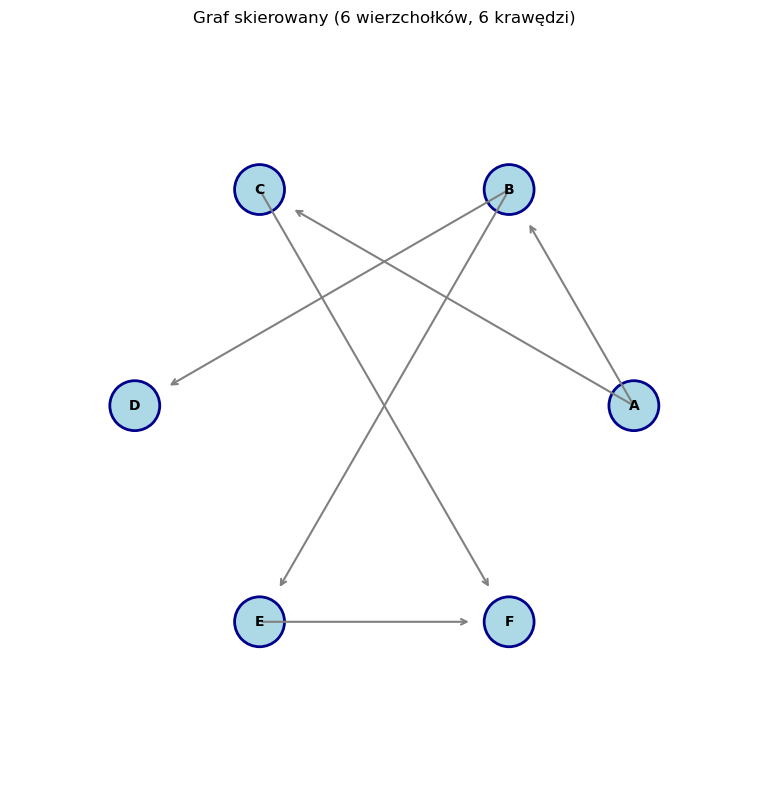

In [9]:
g = Graph(directed=True)
g.add_edges_from_list([
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('B', 'E'),
    ('C', 'F'),
    ('E', 'F')
])

print(f"Graf: {g}")
print(f"DFS (stos) od A: {g.dfs('A')}")
print(f"DFS (rekurencja) od A: {g.dfs_recursive('A')}")
print(f"BFS (kolejka) od A: {g.bfs('A')}")

g.draw()

## Zadanie 4 - Sortowanie topologiczne

In [10]:
def topological_sort(self) -> list[Any]:
    """
    Sortowanie topologiczne grafu skierowanego.
    """
    if not self._directed:
        raise ValueError("Sortowanie topologiczne wymaga grafu skierowanego")
    
    # WHITE=nieodwiedzony, GRAY=w trakcie, BLACK=zakończony
    WHITE, GRAY, BLACK = 0, 1, 2
    color = {v: WHITE for v in self._adjacency_list}
    result = []
    
    def dfs_visit(vertex):
        color[vertex] = GRAY
        
        for neighbor in self.get_neighbors(vertex):
            if color[neighbor] == GRAY:
                raise ValueError(f"Graf zawiera cykl (wykryty przy krawędzi {vertex} -> {neighbor})")
            if color[neighbor] == WHITE:
                dfs_visit(neighbor)
        
        color[vertex] = BLACK  
        result.append(vertex) 
    
    # Odwiedź wszystkie wierzchołki
    for vertex in self._adjacency_list:
        if color[vertex] == WHITE:
            dfs_visit(vertex)
    
    return result[::-1] 

Graph.topological_sort = topological_sort

Kolejność realizacji przedmiotów:
  1. Programowanie
  2. Algorytmy
  3. Struktury danych
  4. Matematyka
  5. Algebra
  6. Algebra liniowa
  7. Grafika komputerowa
  8. Analiza
  9. Równania różniczkowe


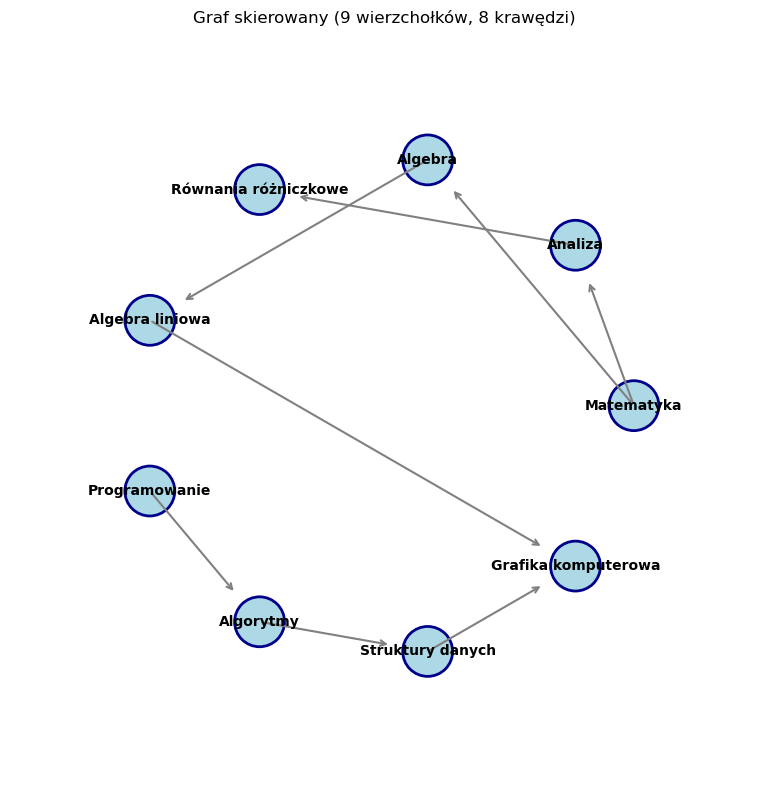

In [11]:
g = Graph(directed=True)
g.add_edges_from_list([
    ('Matematyka', 'Analiza'),
    ('Matematyka', 'Algebra'),
    ('Analiza', 'Równania różniczkowe'),
    ('Algebra', 'Algebra liniowa'),
    ('Programowanie', 'Algorytmy'),
    ('Algorytmy', 'Struktury danych'),
    ('Algebra liniowa', 'Grafika komputerowa'),
    ('Struktury danych', 'Grafika komputerowa')
])

print("Kolejność realizacji przedmiotów:")
for i, subject in enumerate(g.topological_sort(), 1):
    print(f"  {i}. {subject}")

g.draw()

Wykryto cykl: Graf zawiera cykl (wykryty przy krawędzi C -> A)


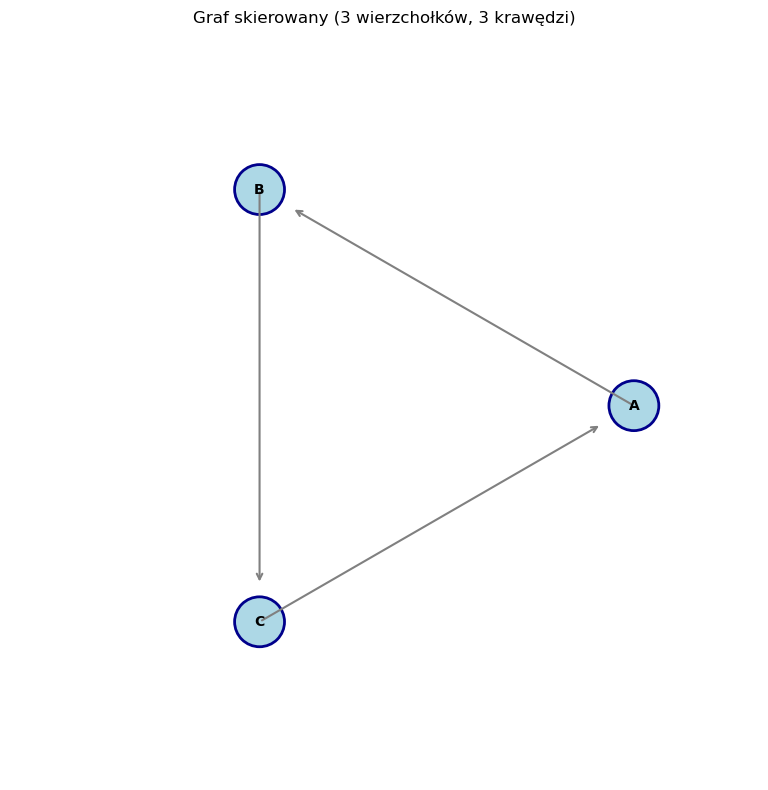

In [12]:
g_cyclic = Graph(directed=True)
g_cyclic.add_edges_from_list([
    ('A', 'B'),
    ('B', 'C'),
    ('C', 'A')  # tworzy cykl
])

try:
    g_cyclic.topological_sort()
except ValueError as e:
    print(f"Wykryto cykl: {e}")

g_cyclic.draw()

## Zadanie 5 - Najkrótsze ścieżki (BFS)

In [13]:
def shortest_paths(self, start: Any) -> tuple[dict[Any, int], dict[Any, Any]]:
    """
    Znajduje najkrótsze ścieżki od wierzchołka startowego do wszystkich innych.
    """
    _, distances, predecessors = self.bfs(start, return_path_info=True)
    return distances, predecessors


def get_path(self, start: Any, end: Any) -> Optional[list[Any]]:
    """
    Zwraca najkrótszą ścieżkę między dwoma wierzchołkami.
    """
    distances, predecessors = self.shortest_paths(start)
    
    if end not in predecessors:
        return None
    
    path = []
    current = end
    while current is not None:
        path.append(current)
        current = predecessors[current]
    
    return path[::-1]


Graph.shortest_paths = shortest_paths
Graph.get_path = get_path

Odległości od A:
  A: 0
  B: 1
  C: 1
  D: 2
  E: 2
  F: 2
Najkrótsza ścieżka A -> E: ['A', 'B', 'E']
Najkrótsza ścieżka A -> F: ['A', 'C', 'F']


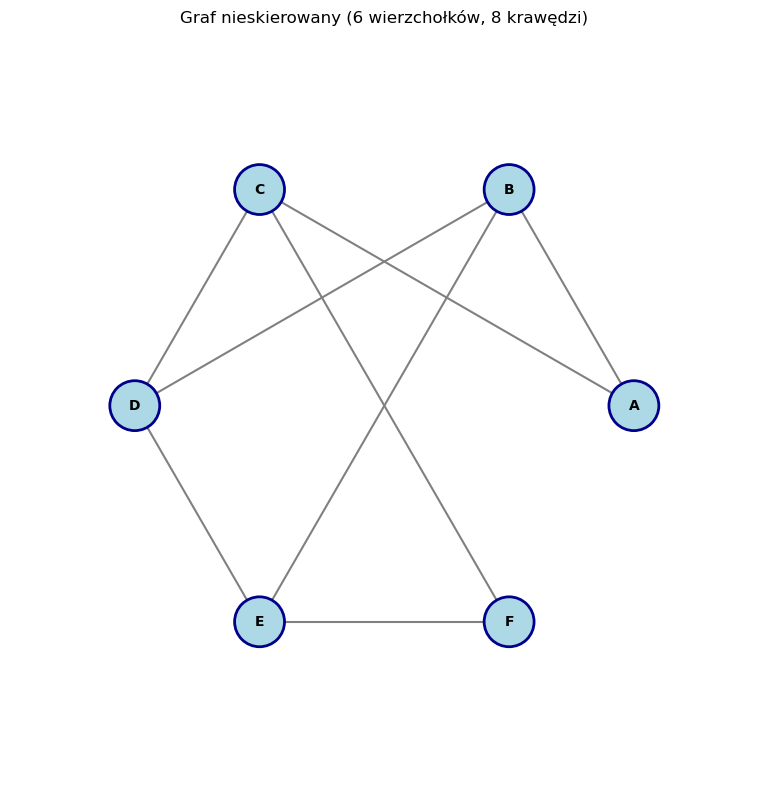

In [14]:
# Test najkrótszych ścieżek
g = Graph(directed=False)
g.add_edges_from_list([
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('C', 'D'),
    ('D', 'E'),
    ('B', 'E'),
    ('C', 'F'),
    ('F', 'E')
])

distances, predecessors = g.shortest_paths('A')

print("Odległości od A:")
for vertex, dist in sorted(distances.items(), key=lambda x: x[1]):
    print(f"  {vertex}: {dist}")

print(f"Najkrótsza ścieżka A -> E: {g.get_path('A', 'E')}")
print(f"Najkrótsza ścieżka A -> F: {g.get_path('A', 'F')}")

g.draw()

## Zadanie 6 - Problem misjonarzy i kanibali

**Problem:** Trzech misjonarzy i trzech kanibali musi przeprawić się przez rzekę łódką, która może pomieścić maksymalnie 2 osoby. Na żadnym brzegu nie może być więcej kanibali niż misjonarzy (inaczej kanibale zjedzą misjonarzy).

**Podejście:**
- Stan: $(m, k, b)$ gdzie $m$ = misjonarze po lewej, $k$ = kanibale po lewej, $b$ = pozycja łodzi ('L' lub 'R')
- Stan początkowy: $(3, 3, L)$
- Stan końcowy: $(0, 0, R)$
- Krawędzie między stanami mają wagę 1
- Używamy BFS do znalezienia najkrótszej ścieżki

In [39]:
def solve_missionaries_cannibals():
    
    def is_valid(m_left, c_left):
        m_right = 3 - m_left
        c_right = 3 - c_left
        
        if not (0 <= m_left <= 3 and 0 <= c_left <= 3):
            return False

        if m_left > 0 and m_left < c_left:
            return False
        
        if m_right > 0 and m_right < c_right:
            return False
        
        return True
    
    # (misjonarze, kanibale)
    moves = [(1, 0), (2, 0), (0, 1), (0, 2), (1, 1)]
    
    graph = Graph(directed=True)
    start = (3, 3, 'L')
    goal = (0, 0, 'R') 
    
    queue = Queue()
    queue.enqueue(start)
    visited = {start}
    
    while not queue.is_empty():
        state = queue.dequeue()
        m_left, c_left, boat = state
        
        for dm, dc in moves:
            if boat == 'L':
                new_m = m_left - dm
                new_c = c_left - dc
                new_boat = 'R'
            else: 
                new_m = m_left + dm
                new_c = c_left + dc
                new_boat = 'L'
            
            new_state = (new_m, new_c, new_boat)
            
            if is_valid(new_m, new_c):
                # Dodaj krawędź z wagą 1
                graph.add_edge(state, new_state, 1)
                if new_state not in visited:
                    visited.add(new_state)
                    queue.enqueue(new_state)
    
    path = graph.get_path(start, goal)
    return path, graph


def format_mc_state(state):
    """Formatuje stan do czytelnej postaci."""
    m_left, c_left, boat = state
    m_right = 3 - m_left
    c_right = 3 - c_left
    boat_pos = "[B]" if boat == 'L' else "   "
    boat_pos_r = "   " if boat == 'L' else "[B]"
    return f"L: {m_left}M {c_left}K {boat_pos} ~~~~ {boat_pos_r} R: {m_right}M {c_right}K"

In [40]:
# Rozwiązanie problemu misjonarzy i kanibali
solution, graph = solve_missionaries_cannibals()

for i, state in enumerate(solution):
    print(f"Krok {i}: {format_mc_state(state)}")
    if i < len(solution) - 1:
        m1, c1, b1 = state
        m2, c2, b2 = solution[i + 1]
        dm = abs(m1 - m2)
        dc = abs(c1 - c2)
        direction = "-->" if b1 == 'L' else "<--"
        print(f"        Przeprawa {direction}: {dm}M {dc}K")

print(f"Graf stanów: {graph}")

Krok 0: L: 3M 3K [B] ~~~~     R: 0M 0K
        Przeprawa -->: 0M 2K
Krok 1: L: 3M 1K     ~~~~ [B] R: 0M 2K
        Przeprawa <--: 0M 1K
Krok 2: L: 3M 2K [B] ~~~~     R: 0M 1K
        Przeprawa -->: 0M 2K
Krok 3: L: 3M 0K     ~~~~ [B] R: 0M 3K
        Przeprawa <--: 0M 1K
Krok 4: L: 3M 1K [B] ~~~~     R: 0M 2K
        Przeprawa -->: 2M 0K
Krok 5: L: 1M 1K     ~~~~ [B] R: 2M 2K
        Przeprawa <--: 1M 1K
Krok 6: L: 2M 2K [B] ~~~~     R: 1M 1K
        Przeprawa -->: 2M 0K
Krok 7: L: 0M 2K     ~~~~ [B] R: 3M 1K
        Przeprawa <--: 0M 1K
Krok 8: L: 0M 3K [B] ~~~~     R: 3M 0K
        Przeprawa -->: 0M 2K
Krok 9: L: 0M 1K     ~~~~ [B] R: 3M 2K
        Przeprawa <--: 1M 0K
Krok 10: L: 1M 1K [B] ~~~~     R: 2M 2K
        Przeprawa -->: 1M 1K
Krok 11: L: 0M 0K     ~~~~ [B] R: 3M 3K
Graf stanów: Graph(skierowany, wierzchołki=16, krawędzie=34)


In [29]:
print(graph.to_dot())

digraph G {
    rankdir=LR;
    node [shape=circle];
    "(3, 3, 'L')";
    "(3, 2, 'R')";
    "(3, 1, 'R')";
    "(2, 2, 'R')";
    "(3, 2, 'L')";
    "(3, 0, 'R')";
    "(3, 1, 'L')";
    "(1, 1, 'R')";
    "(2, 2, 'L')";
    "(0, 2, 'R')";
    "(0, 3, 'L')";
    "(0, 1, 'R')";
    "(1, 1, 'L')";
    "(0, 2, 'L')";
    "(0, 0, 'R')";
    "(0, 1, 'L')";
    "(3, 3, 'L')" -> "(3, 2, 'R')";
    "(3, 3, 'L')" -> "(3, 1, 'R')";
    "(3, 3, 'L')" -> "(2, 2, 'R')";
    "(3, 2, 'R')" -> "(3, 3, 'L')";
    "(3, 1, 'R')" -> "(3, 2, 'L')";
    "(3, 1, 'R')" -> "(3, 3, 'L')";
    "(2, 2, 'R')" -> "(3, 2, 'L')";
    "(2, 2, 'R')" -> "(3, 3, 'L')";
    "(3, 2, 'L')" -> "(2, 2, 'R')";
    "(3, 2, 'L')" -> "(3, 1, 'R')";
    "(3, 2, 'L')" -> "(3, 0, 'R')";
    "(3, 0, 'R')" -> "(3, 1, 'L')";
    "(3, 0, 'R')" -> "(3, 2, 'L')";
    "(3, 1, 'L')" -> "(1, 1, 'R')";
    "(3, 1, 'L')" -> "(3, 0, 'R')";
    "(1, 1, 'R')" -> "(3, 1, 'L')";
    "(1, 1, 'R')" -> "(2, 2, 'L')";
    "(2, 2, 'L')" -> "(0, 2, 'R

## Zadanie 7 - Problem kanistrów z wodą

**Problem:** Odmierz dokładnie 2 litry wody używając dwóch kanistrów o pojemności 3l i 4l.

**Podejście:**
- Stan: $(a, b)$ gdzie $a$ = woda w kanistru 3l, $b$ = woda w kanistru 4l
- Stan początkowy: $(0, 0)$
- Stan końcowy: $(2, x)$ lub $(x, 2)$ dla dowolnego $x$
- Krawędzie między stanami mają wagę 1 (jedna operacja)
- Używamy BFS do znalezienia najkrótszej ścieżki

**Możliwe operacje:**
1. Napełnij kanister do pełna
2. Wylej całą wodę z kanistra
3. Przelej wodę z jednego kanistra do drugiego

In [ ]:
def solve_water_jugs(capacity1: int = 3, capacity2: int = 4, target: int = 2):
    
    def get_next_states(state):
        """Generuje wszystkie możliwe następne stany."""
        a, b = state
        states = []
        
        # 1. Napełnij kanister 1
        states.append((capacity1, b))
        
        # 2. Napełnij kanister 2
        states.append((a, capacity2))
        
        # 3. Wylej kanister 1
        states.append((0, b))
        
        # 4. Wylej kanister 2
        states.append((a, 0))
        
        # 5. Przelej z 1 do 2
        pour = min(a, capacity2 - b)
        states.append((a - pour, b + pour))
        
        # 6. Przelej z 2 do 1
        pour = min(b, capacity1 - a)
        states.append((a + pour, b - pour))
        
        return states
    
    # Budowanie grafu stanów
    graph = Graph(directed=True)
    start = (0, 0)
    
    queue = Queue()
    queue.enqueue(start)
    visited = {start}
    goal_state = None
    
    while not queue.is_empty():
        state = queue.dequeue()
        
        if state[0] == target or state[1] == target:
            if goal_state is None:
                goal_state = state
        
        for next_state in get_next_states(state):
            if next_state != state:
                graph.add_edge(state, next_state, 1)
                if next_state not in visited:
                    visited.add(next_state)
                    queue.enqueue(next_state)
    
    if goal_state is None:
        return None, graph
    
    path = graph.get_path(start, goal_state)
    return path, graph


In [ ]:
# Rozwiązanie problemu kanistrów
CAP1, CAP2, TARGET = 3, 4, 2

def describe_water_action(state1, state2, cap1, cap2):
    """Opisuje akcję przejścia między stanami."""
    a1, b1 = state1
    a2, b2 = state2
    
    if a2 == cap1 and b1 == b2:
        return f"Napełnij kanister {cap1}l"
    elif b2 == cap2 and a1 == a2:
        return f"Napełnij kanister {cap2}l"
    elif a2 == 0 and b1 == b2:
        return f"Wylej kanister {cap1}l"
    elif b2 == 0 and a1 == a2:
        return f"Wylej kanister {cap2}l"
    elif a2 < a1 and b2 > b1:
        return f"Przelej z {cap1}l do {cap2}l"
    elif b2 < b1 and a2 > a1:
        return f"Przelej z {cap2}l do {cap1}l"
    return "?"

solution, graph = solve_water_jugs(CAP1, CAP2, TARGET)

if solution:
    for i, state in enumerate(solution):
        a, b = state
        bar1 = "█" * a + "░" * (CAP1 - a)
        bar2 = "█" * b + "░" * (CAP2 - b)
        print(f"Krok {i}: [{bar1}] {a}l   [{bar2}] {b}l")
        if i < len(solution) - 1:
            action = describe_water_action(state, solution[i + 1], CAP1, CAP2)
            print(f"        --> {action}")
    
    print("-"*60)
    print(f"Rozwiązanie znalezione w {len(solution) - 1} krokach.")
    print(f"Graf stanów: {graph}")

PROBLEM KANISTRÓW Z WODĄ
Odmierz 2l używając kanistrów 3l i 4l
Krok 0: [░░░] 0l   [░░░░] 0l
        --> Napełnij kanister 3l
Krok 1: [███] 3l   [░░░░] 0l
        --> Przelej z 3l do 4l
Krok 2: [░░░] 0l   [███░] 3l
        --> Napełnij kanister 3l
Krok 3: [███] 3l   [███░] 3l
        --> Przelej z 3l do 4l
Krok 4: [██░] 2l   [████] 4l
------------------------------------------------------------
Rozwiązanie znalezione w 4 krokach!
Graf stanów: Graph(skierowany, wierzchołki=14, krawędzie=50)


In [20]:
# Zapis grafu stanów do DOT
print("Graf stanów w formacie DOT:")
print(graph.to_dot())

Graf stanów w formacie DOT:
digraph G {
    rankdir=LR;
    node [shape=circle];
    "(0, 0)";
    "(3, 0)";
    "(0, 4)";
    "(3, 4)";
    "(0, 3)";
    "(3, 1)";
    "(3, 3)";
    "(0, 1)";
    "(2, 4)";
    "(1, 0)";
    "(2, 0)";
    "(1, 4)";
    "(0, 2)";
    "(3, 2)";
    "(0, 0)" -> "(3, 0)";
    "(0, 0)" -> "(0, 4)";
    "(3, 0)" -> "(3, 4)";
    "(3, 0)" -> "(0, 0)";
    "(3, 0)" -> "(0, 3)";
    "(0, 4)" -> "(3, 4)";
    "(0, 4)" -> "(0, 0)";
    "(0, 4)" -> "(3, 1)";
    "(3, 4)" -> "(0, 4)";
    "(3, 4)" -> "(3, 0)";
    "(0, 3)" -> "(3, 3)";
    "(0, 3)" -> "(0, 4)";
    "(0, 3)" -> "(0, 0)";
    "(0, 3)" -> "(3, 0)";
    "(3, 1)" -> "(3, 4)";
    "(3, 1)" -> "(0, 1)";
    "(3, 1)" -> "(3, 0)";
    "(3, 1)" -> "(0, 4)";
    "(3, 3)" -> "(3, 4)";
    "(3, 3)" -> "(0, 3)";
    "(3, 3)" -> "(3, 0)";
    "(3, 3)" -> "(2, 4)";
    "(0, 1)" -> "(3, 1)";
    "(0, 1)" -> "(0, 4)";
    "(0, 1)" -> "(0, 0)";
    "(0, 1)" -> "(1, 0)";
    "(2, 4)" -> "(3, 4)";
    "(2, 4)" -> "(0, 